Using run_id from /Users/lshriver/PycharmProjects/lf-pinn-inverse-schrodinger/data/run_id.txt: 20260425_090326_311200
Loaded 6000 epochs of metrics.


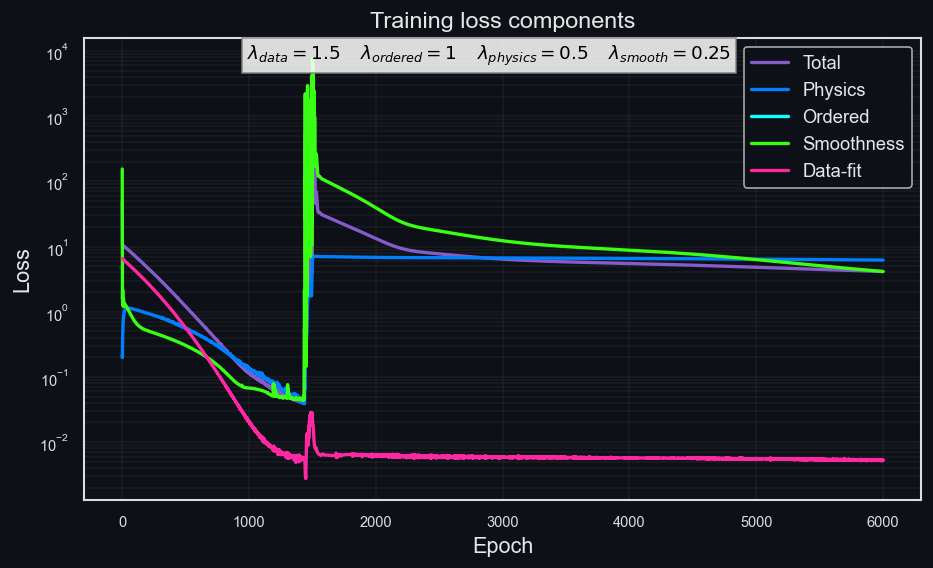

In [1]:
import sys
from pathlib import Path
import json
import sqlite3

# Add project root
PROJECT_ROOT = Path("..").resolve()


import pandas as pd
import matplotlib.pyplot as plt

from visualizations import (
    plot_loss_history,
    plot_potential,
    plot_wavefunctions,
    plot_energy_spectrum,
    plot_pod_singular_values
)

DATA_DIR = PROJECT_ROOT / "data"
DB_PATH = DATA_DIR / "training_runs.db"

# Try to load the latest run_id if available, otherwise use a default or specified one
run_id = "20260424_205517_246896" # Default
run_id = "20260425_085631_749744"
run_id_file = DATA_DIR / "run_id.txt"
if run_id_file.exists():
    run_id = run_id_file.read_text().strip()
    print(f"Using run_id from {run_id_file}: {run_id}")
else:
    print(f"Using default/specified run_id: {run_id}")

RUN_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "runs" / run_id

conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

run_row = conn.execute(
    "SELECT * FROM runs WHERE run_id = ?",
    (run_id,),
).fetchone()

if run_row is None:
    raise KeyError(f"Run not found: {run_id}")

metrics_df = pd.read_sql_query(
    """
    SELECT epoch, total_loss, physics_loss, data_loss, smooth_loss, ordered_loss
    FROM metrics
    WHERE run_id = ?
    ORDER BY epoch ASC
    """,
    conn,
    params=(run_id,),
)

print(f"Loaded {len(metrics_df)} epochs of metrics.")
metrics_df.head()

run_meta = dict(run_row)
hyperparams = json.loads(run_meta["hyperparams"])

# Plot loss history
fig_loss = plot_loss_history(
    epochs=metrics_df["epoch"].values,
    total=metrics_df["total_loss"].values,
    physics=metrics_df["physics_loss"].values,
    data=metrics_df["data_loss"].values,
    smooth=metrics_df["smooth_loss"].values,
    ordered=metrics_df["ordered_loss"].values,
    lambdas=hyperparams["lambdas"]
)
plt.show()

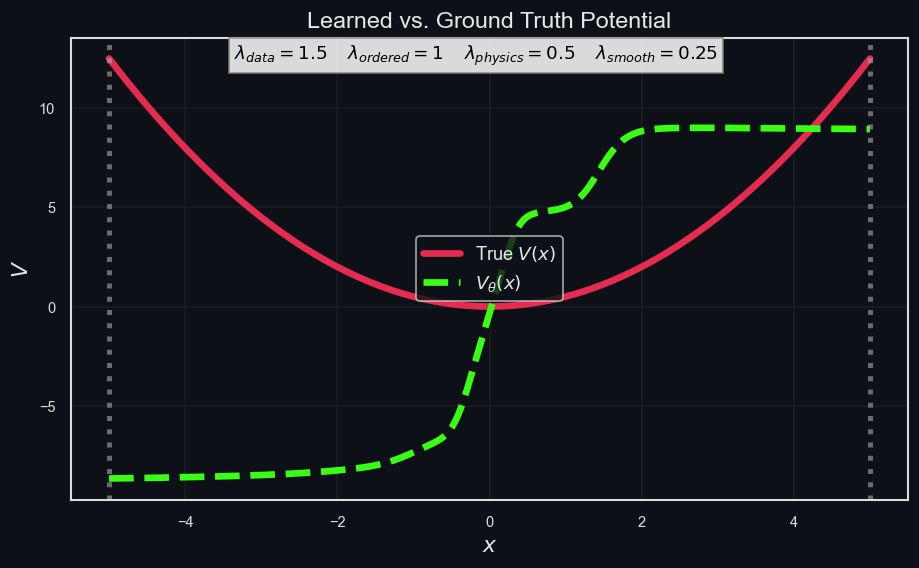

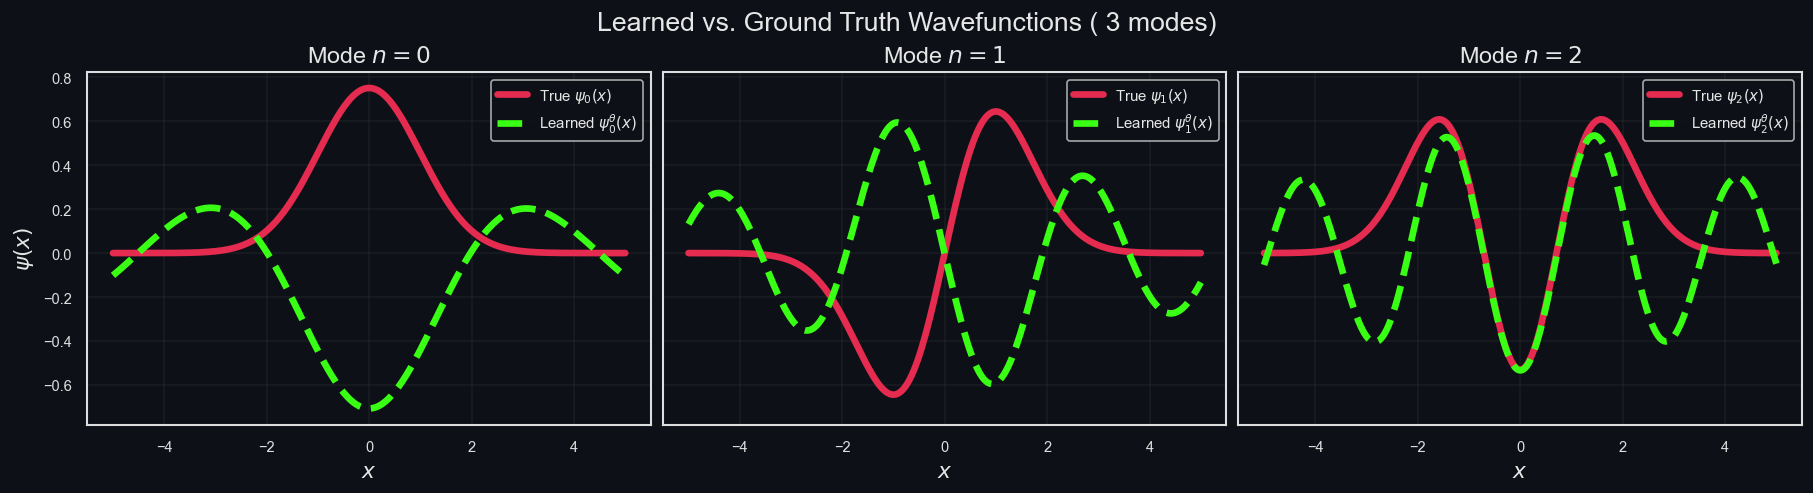

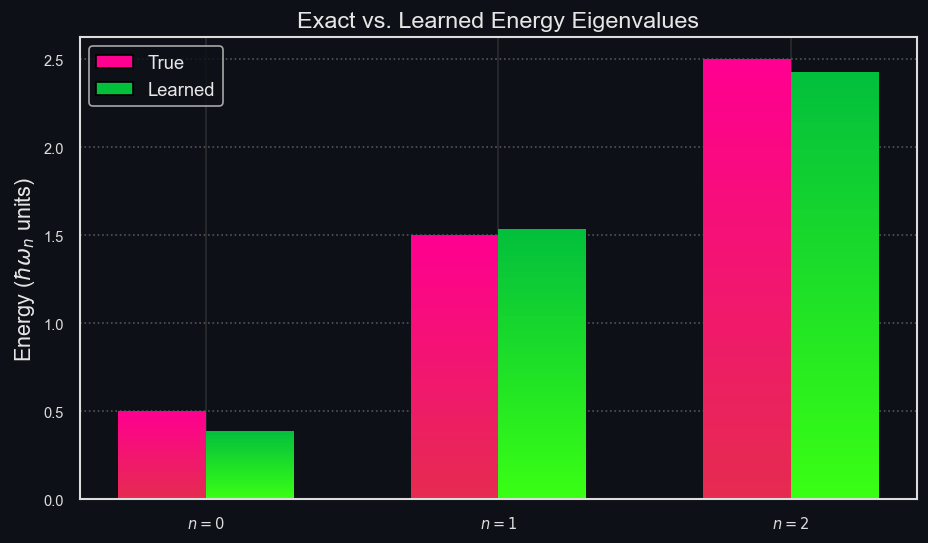


Singular Values:
------------------------------
  Mode (k) |         Sigma_k
------------------------------
         1 |    5.049752e+00
         2 |    5.049752e+00
         3 |    5.049752e+00
------------------------------


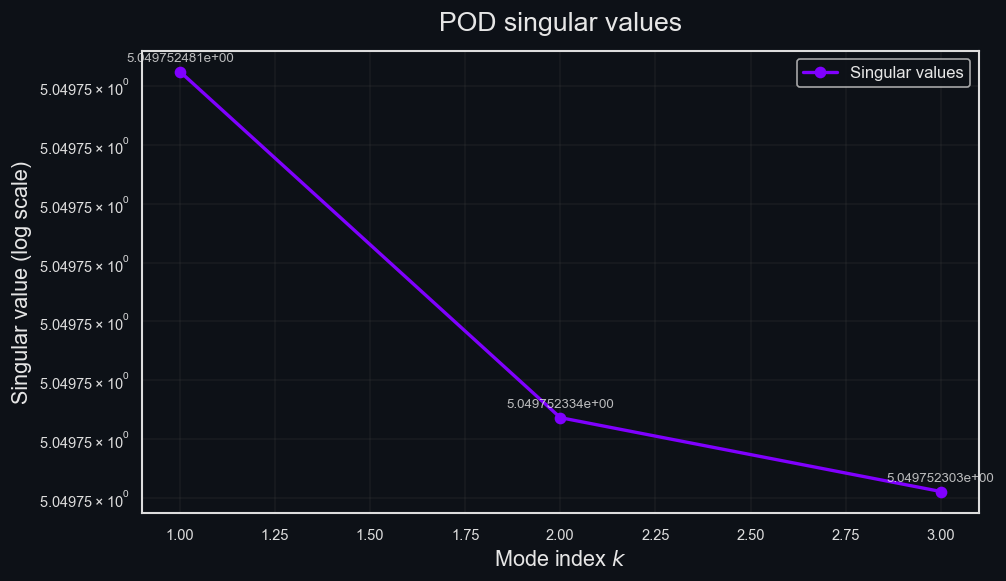

In [2]:
import numpy as np
import torch

# Load artifacts
diagnostics = np.load(RUN_ARTIFACTS_DIR / "diagnostics.npz")
ground_truth = torch.load(RUN_ARTIFACTS_DIR / "ground_truth.pt")

x = ground_truth['x']
V_true = ground_truth['V_true']
psi_true = ground_truth['psi_true']
E_true = ground_truth['E_true']

V_learned = torch.from_numpy(diagnostics['V_learned'])
psi_learned = [torch.from_numpy(p) for p in diagnostics['psi_learned']]
E_learned = torch.from_numpy(diagnostics['E_learned'])
pod_singular_values = torch.from_numpy(diagnostics['pod_singular_values'])

# Visualization 1: Potential
plot_potential(x, V_true, V_learned, hyperparams['lambdas'])
plt.show()

# Visualization 2: Wavefunctions
plot_wavefunctions(x, psi_true, psi_learned)
plt.show()

# Visualization 3: Energy Spectrum
plot_energy_spectrum(E_true, E_learned)
plt.show()

# Visualization 4: POD Singular Values
plot_pod_singular_values(pod_singular_values)
plt.show()

🖥️  Using device: cpu
dx: 0.039215686274509665
x dtype: torch.float64
E_obs dtype: torch.float64
rho_obs[0] dtype: torch.float64
model param dtype: torch.float64
[  800/6000] loss = 2.835771e-01
[ 1600/6000] loss = 2.932600e+01
[ 2400/6000] loss = 8.057318e+00
[ 3200/6000] loss = 6.113193e+00
[ 4000/6000] loss = 5.494827e+00
[ 4800/6000] loss = 4.950169e+00
[ 5600/6000] loss = 4.374977e+00
[ 6000/6000] loss = 4.145996e+00
✅ Training finished. Final loss: 4.145996e+00
Run ID: 20260425_090551_879400
Artifacts saved to: /Users/lshriver/PycharmProjects/lf-pinn-inverse-schrodinger/artifacts/runs/20260425_090551_879400
